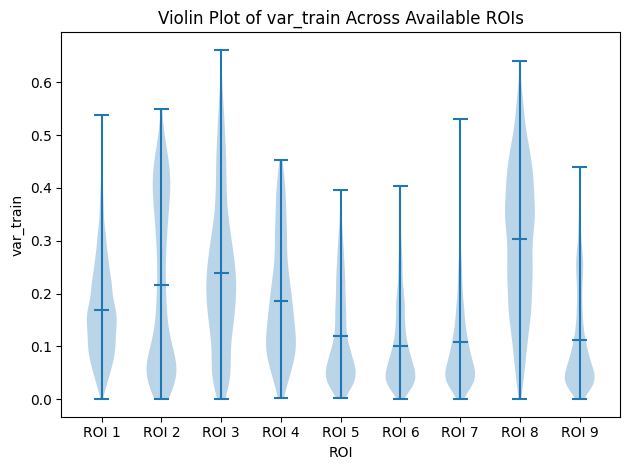

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Prepare file paths for each ROI
roi_nums = range(1, 10)
file_paths = [
    f'data/gaussian_results/subj_01/subj01/fitted_voxels_mask_{roi}.xlsx' 
    for roi in roi_nums
]

# Load var_train data, reporting any missing files
data = []
for roi, path in zip(roi_nums, file_paths):
    if os.path.exists(path):
        df = pd.read_excel(path)
        data.append(df['var_train'])
    else:
        print(f'Warning: File not found for ROI {roi}: {path}')

# Check that we have data to plot
if data:
    # Create violin plot
    plt.figure()
    plt.violinplot(data, showmeans=True)
    plt.xticks(range(1, len(data) + 1), [f'ROI {roi}' for roi in roi_nums if os.path.exists(f'data/gaussian_results/subj_01/subj01/fitted_voxels_mask_{roi}.xlsx')])
    plt.xlabel('ROI')
    plt.ylabel('var_train')
    plt.title('Violin Plot of var_train Across Available ROIs')
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot. Please check your file paths and try again.")


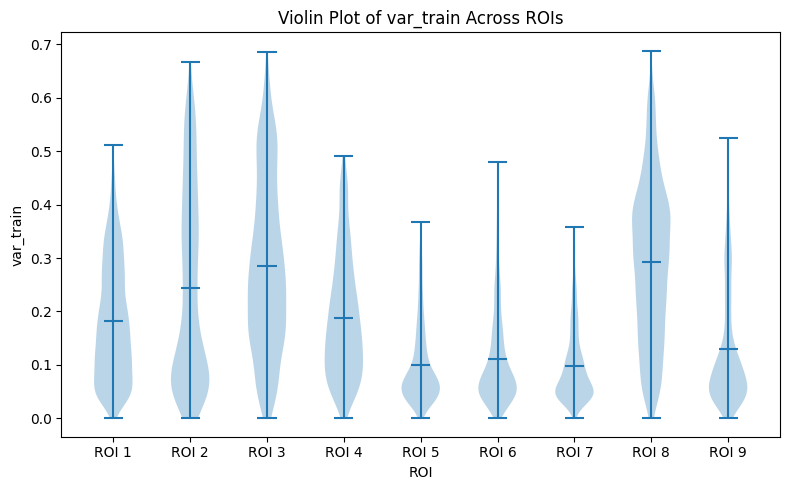

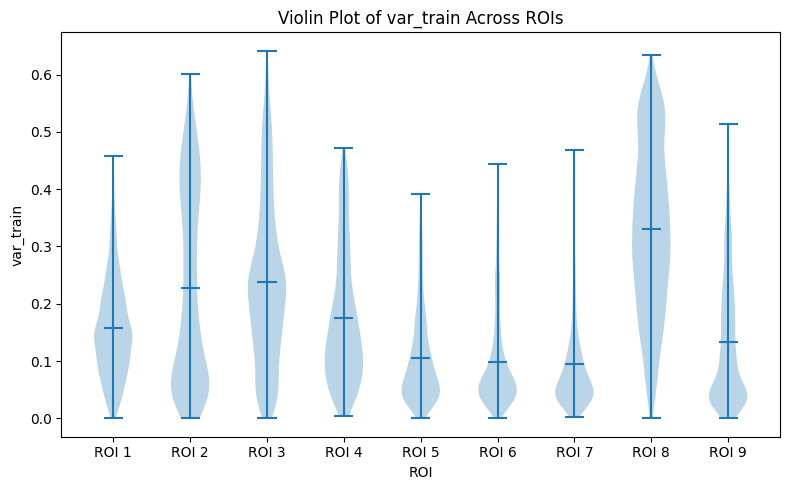

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_violin_for_column(column_name,
                           roi_nums=range(1, 10),
                           base_path='data/gaussian_results/subj_01_without_aug/subj01',
                           file_template='fitted_voxels_mask_{roi}.xlsx'):
    """
    Reads `column_name` from each ROI file and makes a single violin plot.
    
    Parameters
    ----------
    column_name : str
        Name of the column to visualize (e.g. 'var_train', 'var_test', 'sigma', etc.)
    roi_nums : iterable of int
        ROI numbers to include (default 1–9)
    base_path : str
        Directory containing the fitted_voxels files
    file_template : str
        Template for the filenames; must include '{roi}' placeholder
    
    Raises
    ------
    FileNotFoundError
        If none of the specified files are found.
    """
    data = []
    labels = []
    for roi in roi_nums:
        path = os.path.join(base_path, file_template.format(roi=roi))
        if os.path.isfile(path):
            df = pd.read_excel(path)
            if column_name in df.columns:
                data.append(df[column_name])
                labels.append(f'ROI {roi}')
            else:
                print(f"Warning: Column '{column_name}' not in {path}")
        else:
            print(f"Warning: File not found for ROI {roi}: {path}")
    
    if not data:
        raise FileNotFoundError("No valid data loaded; check your paths and column name.")
    
    plt.figure(figsize=(8, 5))
    plt.violinplot(data, showmeans=True)
    plt.xticks(range(1, len(labels) + 1), labels)
    plt.xlabel('ROI')
    plt.ylabel(column_name)
    plt.title(f'Violin Plot of {column_name} Across ROIs')
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_violin_for_column('var_train')
plot_violin_for_column('var_train', base_path='data/gaussian_results/subj_01_without_aug/subj01')
plot_violin_for_column('var_train', base_path='data/gaussian_results/subj_01/subj01')

